<a href="https://colab.research.google.com/github/Bitikameza/EK2026/blob/main/KSCopy_of_Session_I_ML_for_Survival_Analysis_Using_ScikitSurvival_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Session I: Machine Learning for Survival Analysis**: [**`scikit-survival`**](https://scikit-survival.readthedocs.io/en/stable/user_guide/00-introduction.html#Introduction-to-Survival-Analysis-with-scikit-survival)

- [**`scikit-survival`**](https://scikit-survival.readthedocs.io/en/stable/user_guide/00-introduction.html#Introduction-to-Survival-Analysis-with-scikit-survival) is a Python module for survival analysis built on top of [`scikit-learn`](https://scikit-learn.org/stable/).

- Utilizes the power of [`scikit-learn`](https://scikit-learn.org/stable/) for [pre-processing](https://scikit-learn.org/stable/modules/preprocessing.html) and [model selection](https://scikit-learn.org/stable/model_selection.html).



| **Family** | **Import Path** | **Description / Notes** |
|-------------|-----------------|--------------------------|
| **Linear semi-parametric** | `from sksurv.linear_model import CoxPHSurvivalAnalysis` | Standard Cox PHs model |
| | `from sksurv.linear_model import CoxnetSurvivalAnalysis` | Cox model with Elastic-Net penalty (L1 + L2 regularization) |
| **Ensemble Methods** | `from sksurv.ensemble import RandomSurvivalForest`| Random survival forests |
| | `from sksurv.ensemble import ExtraSurvivalTrees` | ExtraTrees variant |
| | `from sksurv.ensemble import GradientBoostingSurvivalAnalysis`| Gradient boosted trees survival analysis. |
| | `from sksurv.ensemble ComponentwiseGradientBoostingSurvivalAnalysis`| Boosting fits one feature at a time. |
| **Support Vector Machine** | `from sksurv.svm import FastSurvivalSVM`| SVM adapted for censored survival data (faster implementation). |
|  | `from sksurv.svm import NaiveSurvivalSVM`| SVR directly to survival times, ignores censoring (assume event happened at censor time). |
| **Non-parametric** | `from sksurv.tree import SurvivalTree`| A single survival decision tree. |


## **1. Prepare Data**

### **i. Import Data**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
ks_df = pd.read_csv("ks_analysis_pythonTDC.csv")
ks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3602 entries, 0 to 3601
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   public_useid   3602 non-null   int64  
 1   age            3602 non-null   int64  
 2   sex            3602 non-null   object 
 3   screat         3502 non-null   float64
 4   albumin        3586 non-null   float64
 5   alp            3601 non-null   float64
 6   astsgot        3601 non-null   float64
 7   tbil           3579 non-null   float64
 8   hemoglobin     3589 non-null   float64
 9   wbc            3589 non-null   float64
 10  anc            3589 non-null   float64
 11  platelets      3562 non-null   float64
 12  karnscr        3602 non-null   int64  
 13  trt1           3602 non-null   object 
 14  cprogwk48      3602 non-null   int64  
 15  progwk48       3602 non-null   float64
 16  cprog          3602 non-null   object 
 17  progwk         3602 non-null   float64
 18  cdthwk48

In [ ]:
cols_to_drop1 = [
    'cprog', 'progwk', 'cdthwk48', 'dthwk48', 'cdth', 'dthwk', 'tstop',
    'event', 'Hard_palate', 'Soft_palate'
]

ks_df = ks_df.drop(columns=cols_to_drop1)

In [ ]:
ks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3602 entries, 0 to 3601
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   public_useid   3602 non-null   int64  
 1   age            3602 non-null   int64  
 2   sex            3602 non-null   object 
 3   screat         3502 non-null   float64
 4   albumin        3586 non-null   float64
 5   alp            3601 non-null   float64
 6   astsgot        3601 non-null   float64
 7   tbil           3579 non-null   float64
 8   hemoglobin     3589 non-null   float64
 9   wbc            3589 non-null   float64
 10  anc            3589 non-null   float64
 11  platelets      3562 non-null   float64
 12  karnscr        3602 non-null   int64  
 13  trt1           3602 non-null   object 
 14  cprogwk48      3602 non-null   int64  
 15  progwk48       3602 non-null   float64
 16  tstart         3602 non-null   int64  
 17  sum            3602 non-null   int64  
 18  raised_l

In [ ]:
ks_df

,public_useid,age,sex,screat,albumin,alp,astsgot,tbil,hemoglobin,wbc,...,tstart,tstop,event,sum,raised_lesion,flat_lesion,Hard_palate,Soft_palate,Right_calf,Left_calf
0,419008056,32,Male,1.052,3.30,95.0,34.0,0.7601,13.5,5.81,...,0,3.0,0,1524,0,49,1.0,1.0,41.0,40.0
1,419008056,32,Male,1.052,3.30,95.0,34.0,0.7601,13.5,5.81,...,3,6.0,0,1524,0,49,1.0,1.0,41.0,40.0
2,419008056,32,Male,1.052,3.30,95.0,34.0,0.7601,13.5,5.81,...,6,9.0,0,1524,0,49,1.0,1.0,41.0,40.0
3,419008056,32,Male,1.052,3.30,95.0,34.0,0.7601,13.5,5.81,...,9,12.0,0,1524,0,49,1.0,1.0,41.0,40.0
4,419008056,32,Male,1.052,3.30,95.0,34.0,0.7601,13.5,5.81,...,12,15.0,0,1504,0,48,1.0,1.0,41.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3597,813388505,36,Male,0.660,3.06,69.0,20.0,0.4200,17.4,2.33,...,3,6.0,0,328,2,36,1.0,2.0,37.0,31.3
3598,813388505,36,Male,0.660,3.06,69.0,20.0,0.4200,17.4,2.33,...,6,9.0,0,294,2,36,1.0,2.0,34.7,31.0
3599,813388505,36,Male,0.660,3.06,69.0,20.0,0.4200,17.4,2.33,...,9,12.0,0,272,2,36,1.0,2.0,37.0,31.3
3600,813388505,36,Male,0.660,3.06,69.0,20.0,0.4200,17.4,2.33,...,12,15.0,0,303,2,36,1.0,2.0,35.0,30.5


In [ ]:
# Copy the dataset
df = ks_df.copy()

# Keep only the rows at timepoints 3, 9, and 18
df_sub = df[df["tstart"].isin([0, 9, 18])]
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
Index: 831 entries, 0 to 3599
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   public_useid   831 non-null    int64  
 1   age            831 non-null    int64  
 2   sex            831 non-null    object 
 3   screat         807 non-null    float64
 4   albumin        824 non-null    float64
 5   alp            830 non-null    float64
 6   astsgot        830 non-null    float64
 7   tbil           825 non-null    float64
 8   hemoglobin     828 non-null    float64
 9   wbc            828 non-null    float64
 10  anc            828 non-null    float64
 11  platelets      822 non-null    float64
 12  karnscr        831 non-null    int64  
 13  trt1           831 non-null    object 
 14  cprogwk48      831 non-null    int64  
 15  progwk48       831 non-null    float64
 16  tstart         831 non-null    int64  
 17  sum            831 non-null    int64  
 18  raised_lesion 

In [ ]:
# TDC variables
tdc_vars = [
    "sum", "raised_lesion", "flat_lesion",
   "Right_calf", "Left_calf"
]

# pivot to wide: baseline_3, wk9_9, wk18_18
wide = df_sub.pivot_table(
    index="public_useid",
    columns="tstart",
    values=tdc_vars
)

wide

Left_calf             Right_calf             flat_lesion         \
tstart              0     9     18         0     9     18          0      9    
public_useid                                                                   
161406            42.0   NaN   NaN       45.5   NaN   NaN        20.0    NaN   
2658083           33.0  34.0  33.2       35.5  34.2  34.0        14.0   14.0   
5919192           34.0  34.5  34.5       34.0  34.5  34.5        22.0   22.0   
9918589           38.2  40.4  32.1       40.6  36.4  39.1        10.0   13.0   
10666732          29.0  29.0   NaN       29.5  29.5   NaN        13.0   13.0   
...                ...   ...   ...        ...   ...   ...         ...    ...   
992848391         38.0  38.0  37.5       36.5  38.0  38.0        15.0   15.0   
993455580         39.4  37.4  37.6       37.1  36.7  37.6         2.0    2.0   
993876913         38.0  35.7  37.5       38.5  37.5  37.5        12.0   12.0   
995251685         31.7   NaN  31.7       31.6   NaN  31.6         0.0    NaN   
999992814         36.6  37.0  35.2       35.2  36.5  37.0       144.0  144.0   

                    raised_lesion                 sum                  
tstart           18            0     9     18      0       9       18  
public_useid                                                           
161406          NaN          35.0   NaN   NaN   490.0     NaN     NaN  
2658083        14.0           0.0   0.0   0.0   358.0   324.0   249.0  
5919192        19.0           0.0   0.0   0.0   696.0   550.0   246.0  
9918589        13.0           8.0   6.0   8.0   675.0   620.0   529.0  
10666732        NaN           7.0   5.0   NaN   852.0   674.0     NaN  
...             ...           ...   ...   ...     ...     ...     ...  
992848391      12.0           0.0   0.0   0.0  3445.0  3330.0  2397.0  
993455580       2.0          40.0  40.0  40.0   534.0   413.0   451.0  
993876913      12.0          10.0  10.0  10.0   237.0   138.0   137.0  
995251685       9.0          10.0   NaN   2.0  2126.0     NaN  1765.0  
999992814     144.0           0.0   0.0   0.0   301.0   273.0   214.0  

[310 rows x 15 columns]

In [ ]:
wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310 entries, 161406 to 999992814
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Left_calf, 0)       303 non-null    float64
 1   (Left_calf, 9)       267 non-null    float64
 2   (Left_calf, 18)      242 non-null    float64
 3   (Right_calf, 0)      296 non-null    float64
 4   (Right_calf, 9)      262 non-null    float64
 5   (Right_calf, 18)     237 non-null    float64
 6   (flat_lesion, 0)     310 non-null    float64
 7   (flat_lesion, 9)     274 non-null    float64
 8   (flat_lesion, 18)    247 non-null    float64
 9   (raised_lesion, 0)   310 non-null    float64
 10  (raised_lesion, 9)   274 non-null    float64
 11  (raised_lesion, 18)  247 non-null    float64
 12  (sum, 0)             310 non-null    float64
 13  (sum, 9)             274 non-null    float64
 14  (sum, 18)            247 non-null    float64
dtypes: float64(15)
memory usage: 38.8 

In [ ]:
# Flatten multi-index columns
wide.columns = [f"{var}_t{time}" for var, time in wide.columns]

# Reset index
wide = wide.reset_index()


In [ ]:
wide

,public_useid,Left_calf_t0,Left_calf_t9,Left_calf_t18,Right_calf_t0,Right_calf_t9,Right_calf_t18,flat_lesion_t0,flat_lesion_t9,flat_lesion_t18,raised_lesion_t0,raised_lesion_t9,raised_lesion_t18,sum_t0,sum_t9,sum_t18
0,161406,42.0,NaN,NaN,45.5,NaN,NaN,20.0,NaN,NaN,35.0,NaN,NaN,490.0,NaN,NaN
1,2658083,33.0,34.0,33.2,35.5,34.2,34.0,14.0,14.0,14.0,0.0,0.0,0.0,358.0,324.0,249.0
2,5919192,34.0,34.5,34.5,34.0,34.5,34.5,22.0,22.0,19.0,0.0,0.0,0.0,696.0,550.0,246.0
3,9918589,38.2,40.4,32.1,40.6,36.4,39.1,10.0,13.0,13.0,8.0,6.0,8.0,675.0,620.0,529.0
4,10666732,29.0,29.0,NaN,29.5,29.5,NaN,13.0,13.0,NaN,7.0,5.0,NaN,852.0,674.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,992848391,38.0,38.0,37.5,36.5,38.0,38.0,15.0,15.0,12.0,0.0,0.0,0.0,3445.0,3330.0,2397.0
306,993455580,39.4,37.4,37.6,37.1,36.7,37.6,2.0,2.0,2.0,40.0,40.0,40.0,534.0,413.0,451.0
307,993876913,38.0,35.7,37.5,38.5,37.5,37.5,12.0,12.0,12.0,10.0,10.0,10.0,237.0,138.0,137.0
308,995251685,31.7,NaN,31.7,31.6,NaN,31.6,0.0,NaN,9.0,10.0,NaN,2.0,2126.0,NaN,1765.0


In [ ]:
### STEP 3: Calculate percentage change
for var in tdc_vars:
    baseline = wide[f"{var}_t0"]

    # avoid division by zero
    baseline_safe = np.where(baseline == 0, 0.0001, baseline)

    wide[f"pc_{var}_9"]  = ((wide[f"{var}_t9"]  - baseline) / baseline_safe) * 100
    wide[f"pc_{var}_18"] = ((wide[f"{var}_t18"] - baseline) / baseline_safe) * 100


In [ ]:
wide

,public_useid,Left_calf_t0,Left_calf_t9,Left_calf_t18,Right_calf_t0,Right_calf_t9,Right_calf_t18,flat_lesion_t0,flat_lesion_t9,flat_lesion_t18,...,pc_sum_9,pc_sum_18,pc_raised_lesion_9,pc_raised_lesion_18,pc_flat_lesion_9,pc_flat_lesion_18,pc_Right_calf_9,pc_Right_calf_18,pc_Left_calf_9,pc_Left_calf_18
0,161406,42.0,NaN,NaN,45.5,NaN,NaN,20.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2658083,33.0,34.0,33.2,35.5,34.2,34.0,14.0,14.0,14.0,...,-9.497207,-30.446927,0.000000,0.0,0.0,0.000000e+00,-3.661972,-4.225352,3.030303,0.606061
2,5919192,34.0,34.5,34.5,34.0,34.5,34.5,22.0,22.0,19.0,...,-20.977011,-64.655172,0.000000,0.0,0.0,-1.363636e+01,1.470588,1.470588,1.470588,1.470588
3,9918589,38.2,40.4,32.1,40.6,36.4,39.1,10.0,13.0,13.0,...,-8.148148,-21.629630,-25.000000,0.0,30.0,3.000000e+01,-10.344828,-3.694581,5.759162,-15.968586
4,10666732,29.0,29.0,NaN,29.5,29.5,NaN,13.0,13.0,NaN,...,-20.892019,NaN,-28.571429,NaN,0.0,NaN,0.000000,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,992848391,38.0,38.0,37.5,36.5,38.0,38.0,15.0,15.0,12.0,...,-3.338171,-30.420900,0.000000,0.0,0.0,-2.000000e+01,4.109589,4.109589,0.000000,-1.315789
306,993455580,39.4,37.4,37.6,37.1,36.7,37.6,2.0,2.0,2.0,...,-22.659176,-15.543071,0.000000,0.0,0.0,0.000000e+00,-1.078167,1.347709,-5.076142,-4.568528
307,993876913,38.0,35.7,37.5,38.5,37.5,37.5,12.0,12.0,12.0,...,-41.772152,-42.194093,0.000000,0.0,0.0,0.000000e+00,-2.597403,-2.597403,-6.052632,-1.315789
308,995251685,31.7,NaN,31.7,31.6,NaN,31.6,0.0,NaN,9.0,...,NaN,-16.980245,NaN,-80.0,NaN,9.000000e+06,NaN,0.000000,NaN,0.000000


In [ ]:
ks_df["tstart"].unique()


array([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45,  7,
       14, 17, 20, 23, 26, 29, 32, 35, 38, 44, 47, 43, 40, 22, 41, 13, 16,
       19, 25, 28, 31, 34, 37, 46, 11, 10])

In [ ]:
wide

,public_useid,Left_calf_t0,Left_calf_t9,Left_calf_t18,Right_calf_t0,Right_calf_t9,Right_calf_t18,flat_lesion_t0,flat_lesion_t9,flat_lesion_t18,...,pc_sum_9,pc_sum_18,pc_raised_lesion_9,pc_raised_lesion_18,pc_flat_lesion_9,pc_flat_lesion_18,pc_Right_calf_9,pc_Right_calf_18,pc_Left_calf_9,pc_Left_calf_18
0,161406,42.0,NaN,NaN,45.5,NaN,NaN,20.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2658083,33.0,34.0,33.2,35.5,34.2,34.0,14.0,14.0,14.0,...,-9.497207,-30.446927,0.000000,0.0,0.0,0.000000e+00,-3.661972,-4.225352,3.030303,0.606061
2,5919192,34.0,34.5,34.5,34.0,34.5,34.5,22.0,22.0,19.0,...,-20.977011,-64.655172,0.000000,0.0,0.0,-1.363636e+01,1.470588,1.470588,1.470588,1.470588
3,9918589,38.2,40.4,32.1,40.6,36.4,39.1,10.0,13.0,13.0,...,-8.148148,-21.629630,-25.000000,0.0,30.0,3.000000e+01,-10.344828,-3.694581,5.759162,-15.968586
4,10666732,29.0,29.0,NaN,29.5,29.5,NaN,13.0,13.0,NaN,...,-20.892019,NaN,-28.571429,NaN,0.0,NaN,0.000000,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,992848391,38.0,38.0,37.5,36.5,38.0,38.0,15.0,15.0,12.0,...,-3.338171,-30.420900,0.000000,0.0,0.0,-2.000000e+01,4.109589,4.109589,0.000000,-1.315789
306,993455580,39.4,37.4,37.6,37.1,36.7,37.6,2.0,2.0,2.0,...,-22.659176,-15.543071,0.000000,0.0,0.0,0.000000e+00,-1.078167,1.347709,-5.076142,-4.568528
307,993876913,38.0,35.7,37.5,38.5,37.5,37.5,12.0,12.0,12.0,...,-41.772152,-42.194093,0.000000,0.0,0.0,0.000000e+00,-2.597403,-2.597403,-6.052632,-1.315789
308,995251685,31.7,NaN,31.7,31.6,NaN,31.6,0.0,NaN,9.0,...,NaN,-16.980245,NaN,-80.0,NaN,9.000000e+06,NaN,0.000000,NaN,0.000000


In [ ]:
baseline_vars = [
    "public_useid", "age", "sex", "screat", "albumin", "alp", "astsgot",
    "tbil", "hemoglobin", "wbc", "anc", "platelets", "karnscr", "trt1"
]

baseline_df = df[df["tstart"] == 0][baseline_vars]

final_df = wide.merge(baseline_df, on="public_useid", how="left")


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   public_useid         310 non-null    int64  
 1   Left_calf_t0         303 non-null    float64
 2   Left_calf_t9         267 non-null    float64
 3   Left_calf_t18        242 non-null    float64
 4   Right_calf_t0        296 non-null    float64
 5   Right_calf_t9        262 non-null    float64
 6   Right_calf_t18       237 non-null    float64
 7   flat_lesion_t0       310 non-null    float64
 8   flat_lesion_t9       274 non-null    float64
 9   flat_lesion_t18      247 non-null    float64
 10  raised_lesion_t0     310 non-null    float64
 11  raised_lesion_t9     274 non-null    float64
 12  raised_lesion_t18    247 non-null    float64
 13  sum_t0               310 non-null    float64
 14  sum_t9               274 non-null    float64
 15  sum_t18              247 non-null    flo

In [ ]:
surv = df.groupby("public_useid").agg(
    event = ("cprogwk48", "max"),
    time  = ("progwk48", "max")
).reset_index()

final_df = final_df.merge(surv, on="public_useid", how="left")


In [ ]:
final_df

,public_useid,Left_calf_t0,Left_calf_t9,Left_calf_t18,Right_calf_t0,Right_calf_t9,Right_calf_t18,flat_lesion_t0,flat_lesion_t9,flat_lesion_t18,...,astsgot,tbil,hemoglobin,wbc,anc,platelets,karnscr,trt1,event,time
0,161406,42.0,NaN,NaN,45.5,NaN,NaN,20.0,NaN,NaN,...,40.73,0.3935,10.7,6.85,1.4400,356.0,80,Pacilitaxel,0,6.000000
1,2658083,33.0,34.0,33.2,35.5,34.2,34.0,14.0,14.0,14.0,...,13.00,0.4900,8.5,9.76,4.9093,352.0,90,Bleomycin/Vincristine,1,27.000000
2,5919192,34.0,34.5,34.5,34.0,34.5,34.5,22.0,22.0,19.0,...,28.00,0.2100,12.7,2.09,0.5601,196.0,90,Pacilitaxel,0,48.000000
3,9918589,38.2,40.4,32.1,40.6,36.4,39.1,10.0,13.0,13.0,...,14.00,0.2000,10.4,4.30,3.1500,315.0,90,Etoposide,0,48.000000
4,10666732,29.0,29.0,NaN,29.5,29.5,NaN,13.0,13.0,NaN,...,37.00,0.4327,12.8,8.00,5.0600,302.0,70,Pacilitaxel,0,14.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,992848391,38.0,38.0,37.5,36.5,38.0,38.0,15.0,15.0,12.0,...,23.00,0.6600,12.8,3.36,2.0160,129.0,90,Bleomycin/Vincristine,0,48.000000
306,993455580,39.4,37.4,37.6,37.1,36.7,37.6,2.0,2.0,2.0,...,14.00,0.2000,11.1,4.40,2.4500,338.0,70,Bleomycin/Vincristine,0,48.000000
307,993876913,38.0,35.7,37.5,38.5,37.5,37.5,12.0,12.0,12.0,...,22.00,0.4000,10.9,2.69,1.2804,217.0,90,Pacilitaxel,1,42.000000
308,995251685,31.7,NaN,31.7,31.6,NaN,31.6,0.0,NaN,9.0,...,26.00,0.3000,12.8,4.40,1.7400,213.0,80,Bleomycin/Vincristine,0,48.000000


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   public_useid         310 non-null    int64  
 1   Left_calf_t0         303 non-null    float64
 2   Left_calf_t9         267 non-null    float64
 3   Left_calf_t18        242 non-null    float64
 4   Right_calf_t0        296 non-null    float64
 5   Right_calf_t9        262 non-null    float64
 6   Right_calf_t18       237 non-null    float64
 7   flat_lesion_t0       310 non-null    float64
 8   flat_lesion_t9       274 non-null    float64
 9   flat_lesion_t18      247 non-null    float64
 10  raised_lesion_t0     310 non-null    float64
 11  raised_lesion_t9     274 non-null    float64
 12  raised_lesion_t18    247 non-null    float64
 13  sum_t0               310 non-null    float64
 14  sum_t9               274 non-null    float64
 15  sum_t18              247 non-null    flo

In [ ]:
final_df["event"].value_counts()

,count
event,
0,206
1,104


In [ ]:
#final_df2 = final_df.dropna(subset=[f"{var}_t0" for var in tdc_vars])
final_df2 = final_df.dropna()
final_df2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 1 to 309
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   public_useid         217 non-null    int64  
 1   Left_calf_t0         217 non-null    float64
 2   Left_calf_t9         217 non-null    float64
 3   Left_calf_t18        217 non-null    float64
 4   Right_calf_t0        217 non-null    float64
 5   Right_calf_t9        217 non-null    float64
 6   Right_calf_t18       217 non-null    float64
 7   flat_lesion_t0       217 non-null    float64
 8   flat_lesion_t9       217 non-null    float64
 9   flat_lesion_t18      217 non-null    float64
 10  raised_lesion_t0     217 non-null    float64
 11  raised_lesion_t9     217 non-null    float64
 12  raised_lesion_t18    217 non-null    float64
 13  sum_t0               217 non-null    float64
 14  sum_t9               217 non-null    float64
 15  sum_t18              217 non-null    float64


In [ ]:
final_df2["event"].value_counts()


,count
event,
0,140
1,77


### **ii. Separate Covariates and Outcomes Data**

In [ ]:
X_df = final_df2.drop(columns=["public_useid", "event", "time"])
Y_df = final_df2[["event", "time"]]
# Y_df

### **iii. Split into Train and Test Sets**

In [ ]:
from sklearn.model_selection import train_test_split
X_train_df, X_test_df, Y_train_df, Y_test_df = train_test_split(X_df, Y_df, stratify=Y_df["event"], test_size=0.30, random_state=42)

In [ ]:
X_train_df.shape, X_test_df.shape

((151, 38), (66, 38))

In [ ]:
X_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 1 to 309
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Left_calf_t0         217 non-null    float64
 1   Left_calf_t9         217 non-null    float64
 2   Left_calf_t18        217 non-null    float64
 3   Right_calf_t0        217 non-null    float64
 4   Right_calf_t9        217 non-null    float64
 5   Right_calf_t18       217 non-null    float64
 6   flat_lesion_t0       217 non-null    float64
 7   flat_lesion_t9       217 non-null    float64
 8   flat_lesion_t18      217 non-null    float64
 9   raised_lesion_t0     217 non-null    float64
 10  raised_lesion_t9     217 non-null    float64
 11  raised_lesion_t18    217 non-null    float64
 12  sum_t0               217 non-null    float64
 13  sum_t9               217 non-null    float64
 14  sum_t18              217 non-null    float64
 15  pc_sum_9             217 non-null    float64


### **iv. Identify Categorical and Quantitative Covariates**

In [ ]:
quant_features = list(X_df.select_dtypes(exclude="object").columns)
quant_features

cat_features = list(X_df.select_dtypes(include="object").columns)
cat_features

['sex', 'trt1']

### **v. Instantiate Data Transformer**

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

cat_transformer = OneHotEncoder(drop="first")
quant_transformer = StandardScaler()

transformer = ColumnTransformer([
    ("CategoricalEncoder", cat_transformer, cat_features),
    ("QuantitativeScaler", quant_transformer, quant_features)])
transformer

ColumnTransformer(transformers=[('CategoricalEncoder',
                                 OneHotEncoder(drop='first'), ['sex', 'trt1']),
                                ('QuantitativeScaler', StandardScaler(),
                                 ['Left_calf_t0', 'Left_calf_t9',
                                  'Left_calf_t18', 'Right_calf_t0',
                                  'Right_calf_t9', 'Right_calf_t18',
                                  'flat_lesion_t0', 'flat_lesion_t9',
                                  'flat_lesion_t18', 'raised_lesion_t0',
                                  'raised_lesion_t9', 'raised_lesion_t18',
                                  'sum_t0', 'sum_t9', 'sum_t18', 'pc_sum_9',
                                  'pc_sum_18', 'pc_raised_lesion_9',
                                  'pc_raised_lesion_18', 'pc_flat_lesion_9',
                                  'pc_flat_lesion_18', 'pc_Right_calf_9',
                                  'pc_Right_calf_18', 'pc_Left_calf_9',
                                  'pc_Left_calf_18', 'age', 'screat', 'albumin',
                                  'alp', 'astsgot', ...])])

### **vi. Transform Train and Test Covariates Data**

In [ ]:
X_train = transformer.fit_transform(X_train_df).astype('float32')
X_test = transformer.transform(X_test_df).astype('float32')

In [ ]:
transformed_covs = [v.split("__", 1)[-1] for v in transformer.get_feature_names_out()]
transformed_covs

['sex_Male',
 'trt1_Etoposide',
 'trt1_Pacilitaxel',
 'Left_calf_t0',
 'Left_calf_t9',
 'Left_calf_t18',
 'Right_calf_t0',
 'Right_calf_t9',
 'Right_calf_t18',
 'flat_lesion_t0',
 'flat_lesion_t9',
 'flat_lesion_t18',
 'raised_lesion_t0',
 'raised_lesion_t9',
 'raised_lesion_t18',
 'sum_t0',
 'sum_t9',
 'sum_t18',
 'pc_sum_9',
 'pc_sum_18',
 'pc_raised_lesion_9',
 'pc_raised_lesion_18',
 'pc_flat_lesion_9',
 'pc_flat_lesion_18',
 'pc_Right_calf_9',
 'pc_Right_calf_18',
 'pc_Left_calf_9',
 'pc_Left_calf_18',
 'age',
 'screat',
 'albumin',
 'alp',
 'astsgot',
 'tbil',
 'hemoglobin',
 'wbc',
 'anc',
 'platelets',
 'karnscr']

### **vii. Convert Train and Test Outcomes Data into Structured Array**

In [ ]:
train_outcome = Y_train_df["event"].astype(bool)
train_time = Y_train_df["time"]
Y_train_tuple = (train_outcome, train_time)

In [ ]:
test_outcome = Y_test_df["event"].astype(bool)
test_time = Y_test_df["time"]

Y_test_tuple = (test_outcome, test_time)

In [ ]:
!pip install scikit-survival -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
from sksurv.util import Surv

Y_train = Surv.from_arrays(event=Y_train_tuple[0], time=Y_train_tuple[1])
Y_test = Surv.from_arrays(*Y_test_tuple)

### **viii. Import Model Classes**

**Import Model Classes**

In [ ]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import ExtraSurvivalTrees
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.ensemble import ComponentwiseGradientBoostingSurvivalAnalysis

from sksurv.svm import FastSurvivalSVM
from sksurv.svm import NaiveSurvivalSVM

from sksurv.tree import SurvivalTree

ImportError: cannot import name '_randomized_svd' from 'sklearn.utils.extmath' (/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py)

## **2. Cox PH Model**

In [ ]:
coxph = CoxPHSurvivalAnalysis()
coxph

CoxPHSurvivalAnalysis()

In [ ]:
coxph.fit(X_train, Y_train)

CoxPHSurvivalAnalysis()

**Coefficients (log hazard ratio)**

In [ ]:
pd.DataFrame({"Covariates": transformed_covs, "Coefficients": coxph.coef_})

,Covariates,Coefficients
0,sex_Male,0.433014
1,trt1_Etoposide,0.696195
2,trt1_Pacilitaxel,-1.644292
3,Left_calf_t0,-0.933761
4,Left_calf_t9,2.008563
5,Left_calf_t18,-0.977447
6,Right_calf_t0,-11.241410
7,Right_calf_t9,7.482885
8,Right_calf_t18,2.947850
9,flat_lesion_t0,-3.902165


### **i. Predictions**

**(Time-Independent) Risk Scores: `.predict()`**

- A relative risk (or hazard) that an individual will experience the event at any given time, compared to others.

- Not a probability but a ranking or scaling of risk.

- Higher risk score implies greater likelihood of experiencing the event sooner.

- The hazard (risk per instant of time) is:

$$h_i(t|\bf{x})=h_0(t)\; e^{\beta_1x_2+\cdots+\beta_dx_d}=h_0(t)\; e^{\hat{R}(\bf{x})}$$
  
- The risk score is: $\hat{R}(\bf{x})=\beta_1x_2+\cdots+\beta_dx_d$.

    - Baseline risk=0
      
    - Negative = lower risk

    - Positive=higher risk

In [ ]:
cph_risk_scores = coxph.predict(X_test)
# cph_risk_scores

**Visualize the Distribution of Risk Scores**

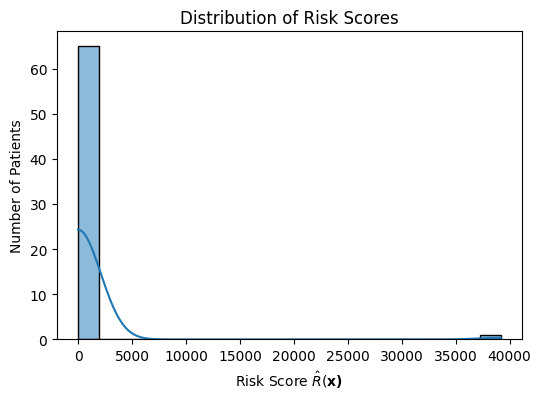

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(cph_risk_scores, bins=20, kde=True)
plt.title("Distribution of Risk Scores")
plt.xlabel(r"Risk Score $\hat{R}(\bf{x})$")
plt.ylabel("Number of Patients")
plt.show()

Interpretation:

- Scores centered around 0 > balanced risk population

- A long right tail → some individuals have significantly higher risk

**Group Patients by Risk Level**

In [ ]:
risk_df = pd.DataFrame({"risk_score": cph_risk_scores})
risk_df["risk_group"] = pd.qcut(risk_df["risk_score"], q=3, labels=["Low", "Medium", "High"])

risk_df.head(10)

,risk_score,risk_group
0,-1.344789,Low
1,0.216795,Medium
2,-2.112277,Low
3,3.853136,High
4,6.127363,High
5,2.313272,High
6,4.226701,High
7,-0.595858,Medium
8,0.204035,Medium
9,-3.024173,Low


In [ ]:
risk_df["risk_group"].value_counts()

,count
risk_group,
Low,22
Medium,22
High,22


**Cumulative Hazard (Time Dependent Risk Scores): `.predict_cumulative_hazard_function()`**

- $H_i(t)$: The cumulative sum of hazard over time (i.e., total accumulated risk of the event up to time $t$).

$$H_i(t)=\int_0^t h_i(u)du $$

- $h_i(t)$ is the instantaneous hazard rate at time $t$.

- Hazard as risk per instant of time.
      
- Cumulative hazard shows how much risk has accumulated up to time  $t$.

    - It starts at 0 and monotonically increases as time goes on.


In [ ]:
cph_haz = coxph.predict_cumulative_hazard_function(X_test)
# cph_haz

/usr/local/lib/python3.12/dist-packages/sksurv/linear_model/coxph.py:105: RuntimeWarning: overflow encountered in exp
  risk_score = np.exp(linear_predictor)


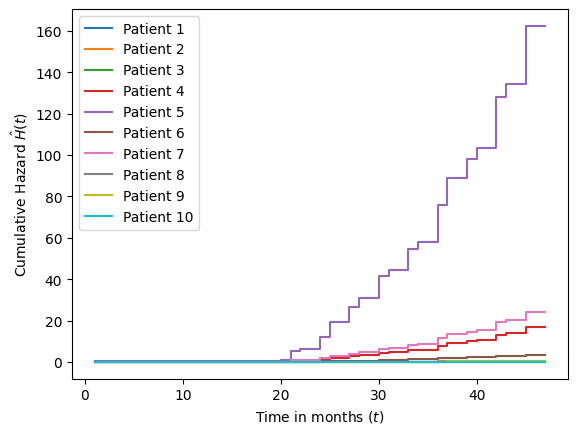

In [ ]:
import matplotlib.pyplot as plt

time_points = np.arange(1, 48)
for i, haz_func in enumerate(cph_haz[:10]):
    plt.step(time_points, haz_func(time_points), where="post", label=f"Patient {i + 1}")
plt.ylabel(r"Cumulative Hazard $\hat{H}(t)$")
plt.xlabel(r"Time in months ($t$)")
plt.legend(loc="best");

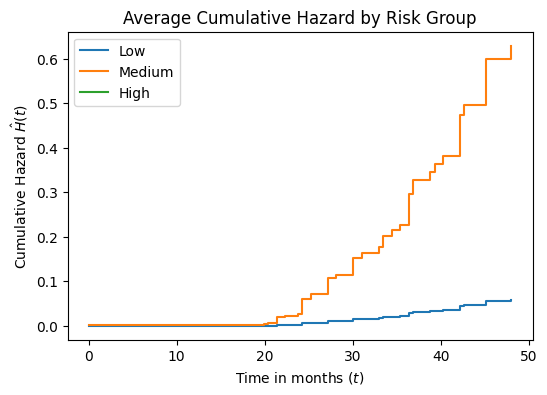

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

for group in ["Low", "Medium", "High"]:
    mask = risk_df["risk_group"] == group
    group_cumhaz = [cph_haz[i] for i in np.where(mask)[0]]

    common_times = np.linspace(0, max([f.x[-1] for f in group_cumhaz]), 100)
    group_values = np.array([f(common_times) for f in group_cumhaz])

    mean_cumhaz = group_values.mean(axis=0)

    plt.step(common_times, mean_cumhaz, where="post", label=group)

plt.ylabel(r"Cumulative Hazard $\hat{H}(t)$")
plt.xlabel(r"Time in months ($t$)")
plt.title("Average Cumulative Hazard by Risk Group")
plt.legend()
plt.show()

**Survival Function**

- What is the chance the patient is still surviving / not defaulted at time $t$?

  $$\hat{S}(t)=\hat{P}(T>t)=e^{-\hat{H}(t)} $$

- If $\hat{S}(t)$ drops quickly, the model predicts high risk / shorter survival (more likely to experience the event sooner).

- If $\hat{S}(t)$ stays near 1, low risk / long survival (less likely to experience the event).

- Prediction of patient-specific survival function `.predict_survival_function()` method.
    
    - That is, a list of survival functions, one per patient.

In [ ]:
cph_surv = coxph.predict_survival_function(X_test)
len(cph_surv)

/usr/local/lib/python3.12/dist-packages/sksurv/linear_model/coxph.py:125: RuntimeWarning: overflow encountered in exp
  risk_score = np.exp(linear_predictor)


66

In [ ]:
# cph_surv[0]

In [ ]:
# cph_surv[0].x  # time points

In [ ]:
# cph_surv[0].y  # survival probabilities

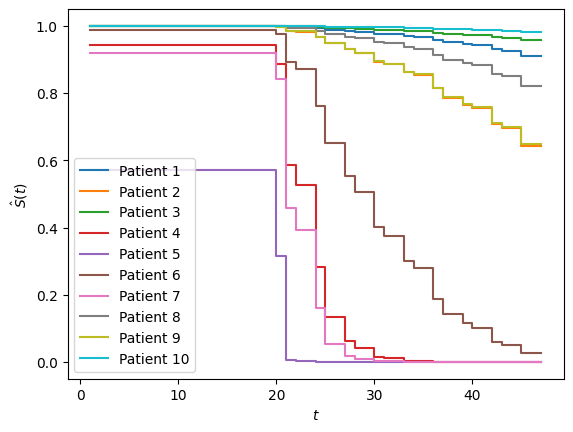

In [ ]:
import matplotlib.pyplot as plt

time_points = np.arange(1, 48)
for i, surv_func in enumerate(cph_surv[:10]):
    plt.step(time_points, surv_func(time_points), where="post", label=f"Patient {i + 1}")
plt.ylabel(r"$\hat{S}(t)$")
plt.xlabel(r"$t$")
plt.legend(loc="best");

**Visualize Survival Curves by Risk Group**

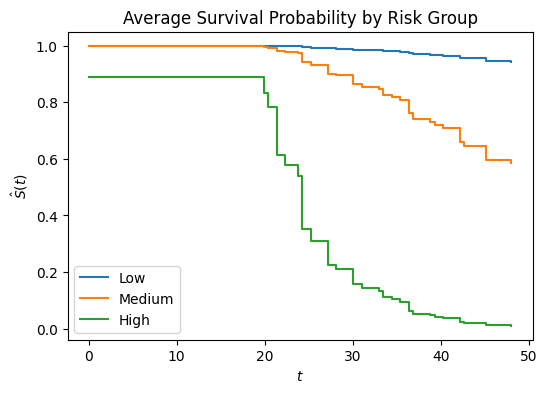

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

for group in ["Low", "Medium", "High"]:
    mask = risk_df["risk_group"] == group
    group_surv = [cph_surv[i] for i in np.where(mask)[0]]

    common_times = np.linspace(0, max([f.x[-1] for f in group_surv]), 100)
    group_values = np.array([f(common_times) for f in group_surv])

    mean_surv = group_values.mean(axis=0)

    plt.step(common_times, mean_surv, where="post", label=group)

plt.xlabel(r"$t$")
plt.ylabel(r"$\hat{S}(t)$")
plt.title("Average Survival Probability by Risk Group")
plt.legend()
plt.show()

### **ii. Performance Measures**

<img src="https://scikit-survival.readthedocs.io/en/stable/_images/metrics-diagram.svg" width="800">

Source: [**`scikit-survival`** documentation](https://scikit-survival.readthedocs.io/en/stable/user_guide/evaluating-survival-models.html)

#### **A. C-index**

- The default performance measure in **`scikit-survival`** is **C-index** (or **Harrell’s concordance index**).

    - C-index measures the model’s ability to correctly rank survival times.
      
    - Generalization of the area under the receiver operating characteristic (ROC) curve

        - A value near 1.0  indicates a better model.
      
        - A value of 0.5 represents a random model.
     
    - It does not measure actual survival probability accuracy, only relative risk ranking.

In [ ]:
coxph.score(X_train, Y_train), coxph.score(X_test, Y_test)

(np.float64(0.8511914154962916), np.float64(0.5785649409627611))

In [ ]:
from sksurv.metrics import (concordance_index_censored,
                            concordance_index_ipcw,
                            cumulative_dynamic_auc,
                            brier_score,
                            integrated_brier_score)

#### **B. `concordance_index_censored()`**

In [ ]:
cph_risk_scores = coxph.predict(X_train)

cindex, concordant, discordant, tied_risk, tied_time = concordance_index_censored(*Y_train_tuple, cph_risk_scores)
cindex, concordant, discordant, tied_risk, tied_time

(np.float64(0.8511914154962916),
 np.int64(5394),
 np.int64(943),
 np.int64(0),
 np.int64(21))

In [ ]:
cph_risk_scores = coxph.predict(X_test)

cindex, concordant, discordant, tied_risk, tied_time = concordance_index_censored(*Y_test_tuple, cph_risk_scores)
cindex, concordant, discordant, tied_risk, tied_time

(np.float64(0.5785649409627611),
 np.int64(637),
 np.int64(464),
 np.int64(0),
 np.int64(71))

- **Concordance index (C-index)**: Measures how well the model’s predicted risk scores rank survival times correctly.
  
- **Concordant pairs**: Number of comparable observation pairs where the model correctly ordered the risks (higher risk → shorter survival).

- **Discordant pairs**: Number of pairs where the model’s risk ordering was wrong.

- **Tied risk pairs**: Pairs where predicted risk scores are equal (no ranking possible).

- **Pairs not comparable**: Number of pairs that could not be compared due to censoring rules.

    - Patient A died at 5 months, patient B is censored at 6 months = comparison is valid (A’s death time is known)

    - Patient A is censored at 5 months, patient B is censored at 6 months = comparison may be invalid (we do not know who would have died first)

#### **C. `concordance_index_ipcw()`**

  - Designed to handle censored data more robustly using inverse probability of censoring weights (IPCW).
    
  - Provides a less biased estimate, especially with high censoring.

  - Inputs are training data for IPCW (used to estimate censoring distribution) and test data

In [ ]:
cph_risk_scores = coxph.predict(X_test)
cindex, concordant, discordant, tied_risk, tied_time = concordance_index_ipcw(Y_train, Y_test, cph_risk_scores)
cindex, concordant, discordant, tied_risk, tied_time

ValueError: censoring survival function is zero at one or more time points

#### **D. `cumulative_dynamic_auc()`**
    
- A time-dependent version of AUC, designed to handle (event and censoring) discrimination at multiple time points.

- How well the predicted risk scores can discriminate between who experiences the event before a given time $t$ and who does not.

In [ ]:
test_times = np.linspace(Y_test["time"].min(), Y_test["time"].max() - 1e-6, 10)
cph_risk_scores = coxph.predict(X_test)
cph_auc, cph_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, cph_risk_scores, test_times)

plt.plot(test_times, cph_auc, marker="o")
plt.axhline(cph_mean_auc, linestyle="--")
plt.xticks(np.arange(0, 48, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

- Average AUC of ~0.63 (dashed line)

- Performace decreases over time (better for ~< 25)

- The model is most effective in predicting defaulting at the initial time.

#### **E. Brier Score`**

- Measures calibration and prediction error over time, not just discrimination like C-index or AUC.
  
- Smaller values are better.

In [ ]:
pred_surv_array = np.asarray([[fn(t) for t in test_times] for fn in cph_surv])

times, brier_scores = brier_score(Y_train, Y_test, pred_surv_array, test_times)
brier_scores

In [ ]:
ibs = integrated_brier_score(Y_train, Y_test, pred_surv_array, test_times)
ibs

In [ ]:
plt.plot(times, brier_scores, label="Brier Score")
plt.axhline(y=ibs, color='r', linestyle='--', label='Integrated Brier Score')
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.legend()
plt.show()

- This shows how prediction error changes over time, with the IBS as a summary.

## **3. [Penalized Cox Models](https://scikit-survival.readthedocs.io/en/stable/user_guide/coxnet.html#Penalized-Cox-Models)**

### **i. Ridge**

In [ ]:
coxpx = CoxPHSurvivalAnalysis()
coxpx.fit(X_train, Y_train)

coxpx.score(X_train, Y_train), coxpx.score(X_test, Y_test)

In [ ]:
ridge_cox = CoxPHSurvivalAnalysis(alpha=1.0)
ridge_cox.fit(X_train, Y_train)

ridge_cox.score(X_train, Y_train), ridge_cox.score(X_test, Y_test)

In [ ]:
alphas = np.logspace(-3, 5, 50).round(4)
coefs_dict = {}

ridge_cox = CoxPHSurvivalAnalysis()
for alpha in alphas:
    ridge_cox.set_params(alpha=alpha)
    ridge_cox.fit(X_train, Y_train)
    coefs_dict[alpha] = ridge_cox.coef_

In [ ]:
coefs_df = pd.DataFrame(coefs_dict)
coefs_df.insert(0, "Covariates", transformed_covs)
coefs_df

In [ ]:
coefs = []
for i,j in coefs_dict.items():
    coefs.append(coefs_dict[i])

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim())
plt.xlabel('Shrinkage effect ($\\alpha$)')
plt.ylabel('Coefficients')
plt.show()

**Hyperparameter Tuning [`GridSearchCV()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#gridsearchcv)**

In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_cox = CoxPHSurvivalAnalysis()
ridge_cox

In [ ]:
hyperparams = {"alpha": np.logspace(-3, 5, 50).round(4)}
hyperparams

In [ ]:
grid_models = GridSearchCV(ridge_cox, param_grid=hyperparams, cv=10, return_train_score=True)
grid_models

In [ ]:
grid_models.fit(X_train, Y_train)
grid_models

In [ ]:
cv_results_df = pd.DataFrame(grid_models.cv_results_)[['param_alpha', 'mean_test_score', 'mean_train_score','rank_test_score']]
cv_results_df

In [ ]:
best_alpha = grid_models.best_params_["alpha"].item()
best_alpha

In [ ]:
best_score = grid_models.best_score_
best_score

In [ ]:
ridge_cox = CoxPHSurvivalAnalysis(alpha=1.8421)
ridge_cox.fit(X_train, Y_train)

In [ ]:
ridge_cox.score(X_train, Y_train), ridge_cox.score(X_test, Y_test)

### **ii. Lasso and Elastic Net**

In [ ]:
# help(CoxnetSurvivalAnalysis())

- Elastic net by default

In [ ]:
enet_cox = CoxnetSurvivalAnalysis()
enet_cox.fit(X_train, Y_train)

In [ ]:
enet_cox.score(X_train, Y_train), enet_cox.score(X_test, Y_test)

In [ ]:
lasso_cox = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[0.05])
lasso_cox.fit(X_train, Y_train)

In [ ]:
lasso_cox.coef_.squeeze()

In [ ]:
lasso_cox.score(X_train, Y_train), lasso_cox.score(X_test, Y_test)

In [ ]:
alphas = np.logspace(-6, 0, 50).round(4)
coefs = []

lasso_cox = CoxnetSurvivalAnalysis(l1_ratio=1)
for alpha in alphas:
    lasso_cox.set_params(alphas=[alpha])
    lasso_cox.fit(X_train, Y_train)
    coefs.append(lasso_cox.coef_.squeeze())

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim())
plt.xlabel('Shrinkage effect ($\\alpha$)')
plt.ylabel('Coefficients')
plt.show()

**Ridge Cox using Elastic Net Cox**

In [ ]:
approx_ridge_cox = CoxnetSurvivalAnalysis(l1_ratio=0.000001)
approx_ridge_cox.fit(X_train, Y_train)

approx_ridge_cox.score(X_train, Y_train), approx_ridge_cox.score(X_test, Y_test)

In [ ]:
enet_cox = CoxnetSurvivalAnalysis()
hyperparams = {"l1_ratio": np.linspace(0.1, 0.9, 20)}
grid_models = GridSearchCV(enet_cox, param_grid=hyperparams, cv=10, return_train_score=True)
grid_models.fit(X_train, Y_train)

In [ ]:
cv_results_df = pd.DataFrame(grid_models.cv_results_)[['param_l1_ratio', 'mean_test_score', 'mean_train_score','rank_test_score']]
best_l1_ratio = grid_models.best_params_["l1_ratio"].item()
best_score = grid_models.best_score_
best_l1_ratio, best_score

In [ ]:
enet_cox = CoxnetSurvivalAnalysis(l1_ratio=0.6052)
enet_cox.fit(X_train, Y_train)
enet_cox.score(X_train, Y_train), enet_cox.score(X_test, Y_test)

- Cox PHs model can only predict a risk score that is independent of time (due to the built-in PHs assumption).

- Therefore, a single predicted risk score needs to work well for every time point.

- In contrast, an ML model such as Random Survival Forest does not have this restriction.

## **4. Random Survival Forest**

In [ ]:
rsf = RandomSurvivalForest(random_state=42)
rsf.fit(X_train, Y_train)

rsf.score(X_train, Y_train), rsf.score(X_test, Y_test)

In [ ]:
rsf_risk_scores = rsf.predict(X_test)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, rsf_risk_scores, test_times)

plt.plot(test_times, rsf_auc, marker="o")
plt.axhline(rsf_mean_auc, linestyle="--")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

In [ ]:
# help(RandomSurvivalForest(random_state=42))

In [ ]:
# rsf = RandomSurvivalForest(random_state=42)
# hyperparams = {"n_estimators": [50, 100, 500],
#               "min_samples_split": [4, 6],
#               "min_samples_leaf": [4]}
# grid_models = GridSearchCV(rsf, param_grid=hyperparams, cv=10, return_train_score=True)
# grid_models.fit(X_train, Y_train)

In [ ]:
# cv_results_df = pd.DataFrame(grid_models.cv_results_)
# best_params = grid_models.best_params_
# best_score = grid_models.best_score_
# best_params, best_score

In [ ]:
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=4, min_samples_leaf=4, random_state=42)
rsf.fit(X_train, Y_train)
rsf.score(X_train, Y_train), rsf.score(X_test, Y_test)

In [ ]:
### **IV. Extra Trees Survival Model**

In [ ]:
extra = ExtraSurvivalTrees()
extra.fit(X_train, Y_train)

extra.score(X_train, Y_train), extra.score(X_test, Y_test)

In [ ]:
extra_risk_scores = extra.predict(X_test)
extra_auc, extra_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, extra_risk_scores, test_times)

plt.plot(test_times, extra_auc, marker="o")
plt.axhline(extra_mean_auc, linestyle="--")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

## **5. Gradient Boosting Survival Model**

In [ ]:
gbs = GradientBoostingSurvivalAnalysis()
gbs.fit(X_train, Y_train)

gbs.score(X_train, Y_train), gbs.score(X_test, Y_test)

In [ ]:
gbs_risk_scores = gbs.predict(X_test)
gbs_auc, gbs_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, gbs_risk_scores, test_times)

plt.plot(test_times, gbs_auc, marker="o")
plt.axhline(gbs_mean_auc, linestyle="--")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

In [ ]:
cgbs = ComponentwiseGradientBoostingSurvivalAnalysis()
cgbs.fit(X_train, Y_train)

cgbs.score(X_train, Y_train), cgbs.score(X_test, Y_test)

In [ ]:
cgbs_risk_scores = cgbs.predict(X_test)
cgbs_auc, cgbs_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, cgbs_risk_scores, test_times)

plt.plot(test_times, cgbs_auc, marker="o")
plt.axhline(cgbs_mean_auc, linestyle="--")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

## **6. Survival SVM**

In [ ]:
svm = FastSurvivalSVM(max_iter=1000, tol=1e-5, random_state=42)
svm.fit(X_train, Y_train)

svm.score(X_train, Y_train), svm.score(X_test, Y_test)

In [ ]:
svm_risk_scores = cgbs.predict(X_test)
svm_auc, svm_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, svm_risk_scores, test_times)

plt.plot(test_times, svm_auc, marker="o")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
plt.axhline(svm_mean_auc, linestyle="--")
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

In [ ]:
nsvm = NaiveSurvivalSVM()
nsvm.fit(X_train, Y_train)

nsvm.score(X_train, Y_train), nsvm.score(X_test, Y_test)

In [ ]:
nsvm_risk_scores = nsvm.predict(X_test)
nsvm_auc, nsvm_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, nsvm_risk_scores, test_times) #(val and test)

plt.plot(test_times, nsvm_auc, marker="o")
plt.axhline(nsvm_mean_auc, linestyle="--")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

## **7. Survival Tree**

In [ ]:
stree = SurvivalTree()
stree.fit(X_train, Y_train)

stree.score(X_train, Y_train), nsvm.score(X_test, Y_test)

In [ ]:
stree_risk_scores = stree.predict(X_test)
stree_auc, stree_mean_auc = cumulative_dynamic_auc(Y_train, Y_test, stree_risk_scores, test_times)

plt.plot(test_times, stree_auc, marker="o")
plt.axhline(stree_mean_auc, linestyle="--")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
# plt.grid(True)
plt.xlabel("Time-to-defaulting from HAART")
plt.ylabel("Time-dependent AUC");

In [ ]:
plt.plot(test_times, cph_auc, "o--", label=f"CoxPH (mean AUC = {cph_mean_auc:.4f})")
plt.plot(test_times, rsf_auc, "v-.", label=f"RSF (mean AUC = {rsf_mean_auc:.4f})")
plt.plot(test_times, extra_auc, "+-", label=f"ExtraT (mean AUC = {extra_mean_auc:.4f})")
plt.plot(test_times, gbs_auc, "D-", label=f"GBS (mean AUC = {gbs_mean_auc:.4f})")
plt.plot(test_times, cgbs_auc, "*-", label=f"CBGS (mean AUC = {cgbs_mean_auc:.4f})")
plt.plot(test_times, svm_auc, "h-", label=f"SVM (mean AUC = {svm_mean_auc:.4f})")
plt.plot(test_times, nsvm_auc, "p-", label=f"NSVM (mean AUC = {nsvm_mean_auc:.4f})")
plt.plot(test_times, stree_auc, "s:", label=f"STree (mean AUC = {stree_mean_auc:.4f})")
plt.xticks(np.arange(0, 55, 6))
plt.yticks(np.arange(0.40, 1.01, 0.10))
plt.xlabel("Time-to-defaulting from HAART treatment")
plt.ylabel("Time-dependent AUC")
# plt.grid(True)
plt.legend(loc="best");

## **8. Feature Importance**

- Which variable is most predictive?

### **i. Coefficients for Linear Models**

  - The magnitude (**absolute value**) reflects the **strength** of the effect.

### **ii. Feature Importance in Tree-Based models**
  
  - With `.feature_importances_` attribute

  - Feature importance is usually based on splits (e.g., Gini importance, gain, permutation importance).

  - These values are non-negative (they measure contribution to reducing error/impurity).

  - Let us see the feature importance of the covariate in the best model selected above.

In [ ]:
gbs.feature_importances_

In [ ]:
gbs_importance_df = pd.DataFrame({'Feature': transformed_covs, 'Importance': gbs.feature_importances_})
gbs_importance_df = gbs_importance_df.sort_values(by='Importance', ascending=False)
gbs_importance_df

### **iii. Permutation Importance** (model-agnostic)

- If a feature’s importance is negative, it means the model does worse when the feature is shuffled.

- That is, the feature was not truly useful (may be just noise or correlated with others).

- Negative permutation importance implies the feature likely adds noise rather than signal.

- Zero importance means "no importance."

In [ ]:
from sklearn.inspection import permutation_importance

importance_summaries = permutation_importance(gbs, X_test, Y_test, n_repeats=15, random_state=42)
# importance_summaries

In [ ]:
importance_summaries_df = pd.DataFrame({k: importance_summaries[k] for k in ("importances_mean", "importances_std")},
                                       index=transformed_covs).sort_values(by="importances_mean", ascending=False)
importance_summaries_df

In [ ]:
import matplotlib.pyplot as plt

# Convert to a Series for easy plotting
gboost_importance_series = importance_summaries_df["importances_mean"]

# Plot the Top 30 features (largest importance values)
plt.figure(figsize=(10, 12))
gboost_importance_series.sort_values().tail(30).plot.barh()

plt.title("Gradient Boosting Survival Model\nPermutation Feature Importance (Top 30)")
plt.xlabel("Mean C-index Drop After Shuffling")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
!pip install shap -q

import shap
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
explainer = shap.TreeExplainer(gbs)
shap_values = explainer.shap_values(X_test)


In [ ]:
explainer = shap.TreeExplainer(gbs)
shap_values = explainer.shap_values(X_test)
